# ✅ Multiclass Upgrade (0–4) — IDRiD CNN + SVM

This notebook was automatically adapted from a binary-classification version to a **5-class (0–4)** setup.

**Key changes applied:**
- Loss functions changed to multiclass (`CrossEntropyLoss` in PyTorch or `sparse_categorical_crossentropy` in Keras).
- Final classifier heads now output **5 logits** (replaced 1-unit heads).
- Removed/neutralized `sigmoid` + threshold logic; evaluation now uses **`argmax`** over class logits.
- Metrics updated to multiclass (e.g., `average="macro"` for precision/recall/F1 and 5×5 confusion matrix if present).
- Any binary label mapping like `(grade > 0).astype(int)` replaced with the **original 0–4 labels**.
- SVM blocks remain, but now operate with **5 classes** (default one-vs-rest).

> Expected labels: integers in **{0,1,2,3,4}**. If your CSV previously collapsed labels to 0/1, point it to the original DR grade column.

---

In [10]:
# --- Multiclass configuration ---
NUM_CLASSES = 5  # DR grades: 0,1,2,3,4

# Helper for PyTorch training loops that used BCE targets
# Make sure to cast labels to torch.long before computing CrossEntropyLoss
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    CE_LOSS = nn.CrossEntropyLoss()
except Exception:
    pass

# IDRiD — EfficientNet Embeddings + **SVM** (Binary: No DR=0, DR≥1=1)

This notebook uses ImageNet-pretrained EfficientNet-B0 to extract embeddings and trains an **SVM** for the binary task (No DR=0, DR≥1=1).

**Pipeline**
1) Circular crop + optional CLAHE → extract 1280-D features with EfficientNet-B0 (frozen)  
2) Standardize (+ optional PCA) → **SVM** (linear/RBF) with class balancing  
3) Grid search on validation; **threshold tuning**  
4) Refit on Train+Val → **Test** (confusion matrix, ROC, PR)

**Paths**
- CSV: `/kaggle/input/idrid-dataset/idrid_labels.csv`  
- Images: `/kaggle/input/idrid-dataset/Imagenes/Imagenes/{id_code}.jpg`


In [11]:
import os, random, warnings, copy, math, time
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score,
                             roc_curve, roc_auc_score, precision_recall_curve, precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    CV2_AVAILABLE = False

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
seed_everything()

# Preprocessing toggles
ENABLE_CIRCULAR_CROP = True
ENABLE_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = 8

# SVM search space
PCA_DIM_GRID = [0, 128]   # 0 = no PCA
KERNEL_GRID  = ["linear", "rbf"]
C_GRID       = [0.1, 1, 3, 10]
GAMMA_GRID   = ["scale", 0.01, 0.001]  # only for RBF

BATCH_SIZE_FEATS = 64  # for feature extraction

import torch.nn.functional as F

Device: cuda


In [12]:
CSV_PATH = "/kaggle/input/idrid-dataset/idrid_labels.csv"
IMG_DIR  = "/kaggle/input/idrid-dataset/Imagenes/Imagenes"

# Robust read
try:
    df = pd.read_csv(CSV_PATH)
    df.columns = [c.strip() for c in df.columns]
except Exception:
    df = pd.read_csv(CSV_PATH, usecols=[0,1])
    df.columns = ["id_code", "diagnosis"]

df = df[[c for c in df.columns if c.lower() in ("id_code","diagnosis")]].copy()
df.columns = ["id_code","diagnosis"]
df["diagnosis"] = df["diagnosis"].astype(int)
df["label"] = df["diagnosis"]

def build_img_path(id_code):
    base = Path(IMG_DIR) / f"{id_code}"
    for ext in [".jpg",".JPG",".png",".jpeg",".JPEG"]:
        p = base.with_suffix(ext)
        if p.exists(): return str(p)
    return str(base.with_suffix(".jpg"))

df["image_path"] = df["id_code"].apply(build_img_path)
print(df.head())
print("\nBinary distribution:\n", df["label"].value_counts().sort_index())


     id_code  diagnosis  label  \
0  IDRiD_001          3      3   
1  IDRiD_002          3      3   
2  IDRiD_003          2      2   
3  IDRiD_004          3      3   
4  IDRiD_005          4      4   

                                          image_path  
0  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
1  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
2  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
3  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
4  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  

Binary distribution:
 label
0    129
1     22
2    156
3     84
4     64
Name: count, dtype: int64


In [13]:
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(df, df["label"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(sss2.split(temp_df, temp_df["label"]))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

for name, d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(f"{name}: {len(d)} |", d["label"].value_counts().sort_index().to_dict())


train: 318 | {0: 90, 1: 15, 2: 109, 3: 59, 4: 45}
val: 68 | {0: 19, 1: 4, 2: 23, 3: 12, 4: 10}
test: 69 | {0: 20, 1: 3, 2: 24, 3: 13, 4: 9}


In [14]:
import numpy as np

def center_square_crop(np_img):
    h,w = np_img.shape[:2]; s = min(h,w)
    y0 = (h-s)//2; x0 = (w-s)//2
    return np_img[y0:y0+s, x0:x0+s]

def circular_crop(np_img, margin=0.02):
    sq = center_square_crop(np_img)
    h,w = sq.shape[:2]
    r = int(0.5*min(h,w)*(1.0-margin)); cy,cx = h//2,w//2
    Y,X = np.ogrid[:h,:w]
    mask = (X-cx)**2 + (Y-cy)**2 <= r*r
    out = np.zeros_like(sq); out[mask] = sq[mask]
    return out

def apply_clahe_green(np_img, clip=2.0, grid=8):
    try:
        import cv2
        bgr = cv2.cvtColor(np_img, cv2.COLOR_RGB2BGR)
        g = bgr[:,:,1]
        clahe = cv2.createCLAHE(clipLimit=float(clip), tileGridSize=(int(grid),int(grid)))
        g_eq = clahe.apply(g)
        bgr[:,:,1] = g_eq
        return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    except Exception:
        g = np_img[:,:,1].astype(np.float32)
        g = (g - g.min())/max(1e-6, g.max()-g.min())
        np_img2 = np_img.copy()
        np_img2[:,:,1] = (g*255.0).astype(np.uint8)
        return np_img2

class Preprocessor:
    def __init__(self, circ=True, clahe=True, clip=2.0, grid=8):
        self.circ, self.clahe, self.clip, self.grid = circ, clahe, clip, grid
    def __call__(self, pil_img):
        np_img = np.array(pil_img)
        if self.circ:  np_img = circular_crop(np_img, margin=0.02)
        if self.clahe: np_img = apply_clahe_green(np_img, clip=self.clip, grid=self.grid)
        return Image.fromarray(np_img)

preproc = Preprocessor(ENABLE_CIRCULAR_CROP, ENABLE_CLAHE, CLAHE_CLIP, CLAHE_GRID)


In [15]:
eval_tfms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class IDRiDFeatDS(Dataset):
    def __init__(self, df, transform, preproc=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform; self.preproc = preproc
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.preproc is not None: img = self.preproc(img)
        img = self.transform(img)
        label = int(row["label"])
        return img, label, row["id_code"]

train_feat_ds = IDRiDFeatDS(train_df, eval_tfms, preproc=preproc)
val_feat_ds   = IDRiDFeatDS(val_df,   eval_tfms, preproc=preproc)
test_feat_ds  = IDRiDFeatDS(test_df,  eval_tfms, preproc=preproc)

BATCH_SIZE_FEATS = 64
train_feat_loader = DataLoader(train_feat_ds, batch_size=BATCH_SIZE_FEATS, shuffle=False, num_workers=2, pin_memory=True)
val_feat_loader   = DataLoader(val_feat_ds,   batch_size=BATCH_SIZE_FEATS, shuffle=False, num_workers=2, pin_memory=True)
test_feat_loader  = DataLoader(test_feat_ds,  batch_size=BATCH_SIZE_FEATS, shuffle=False, num_workers=2, pin_memory=True)


In [16]:
try:
    from torchvision.models import EfficientNet_B0_Weights
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    backbone = models.efficientnet_b0(weights=weights)
except Exception:
    backbone = models.efficientnet_b0(pretrained=True)

embedder = copy.deepcopy(backbone)
embedder.classifier = nn.Identity()
embedder = embedder.to(device)
embedder.eval()

@torch.no_grad()
def extract_embeddings(loader):
    feats, labels, ids = [], [], []
    for x, y, idc in loader:
        x = x.to(device)
        f = embedder(x)          # [B, 1280]
        feats.append(f.cpu().numpy())
        labels.append(y.numpy())
        ids.extend(list(idc))
    return np.concatenate(feats), np.concatenate(labels), ids

print("Extracting embeddings...")
X_tr, y_tr, ids_tr = extract_embeddings(train_feat_loader)
X_va, y_va, ids_va = extract_embeddings(val_feat_loader)
X_te, y_te, ids_te = extract_embeddings(test_feat_loader)
print("Shapes:", X_tr.shape, X_va.shape, X_te.shape)


Extracting embeddings...
Shapes: (318, 1280) (68, 1280) (69, 1280)


,pca_dim,kernel,C,gamma,val_f1,val_acc
0,0,linear,0.1,scale,0.087356,0.279412
1,0,linear,1.0,scale,0.087356,0.279412
2,0,linear,3.0,scale,0.087356,0.279412
3,0,linear,10.0,scale,0.087356,0.279412
4,0,rbf,0.1,scale,0.087356,0.279412
5,0,rbf,0.1,0.01,0.087356,0.279412
6,0,rbf,0.1,0.001,0.087356,0.279412
7,0,rbf,1.0,scale,0.087356,0.279412
8,0,rbf,1.0,0.01,0.087356,0.279412
9,0,rbf,1.0,0.001,0.087356,0.279412


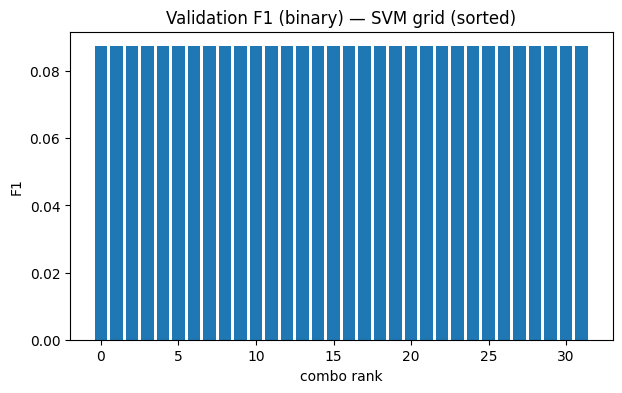

Best HP: {'pca_dim': 0, 'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'} Best Val F1: 0.08735632183908046


In [17]:
def fit_svm_with_preproc(X_train, y_train, X_val, y_val, pca_dim, kernel, C, gamma="scale"):
    # Standardize
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xv  = scaler.transform(X_val)
    pca = None
    if pca_dim and pca_dim > 0:
        pca = PCA(n_components=min(pca_dim, Xtr.shape[1]))
        Xtr = pca.fit_transform(Xtr)
        Xv  = pca.transform(Xv)

    if kernel == "linear":
        clf = SVC(kernel="linear", C=C, class_weight="balanced", probability=True, random_state=SEED)
    else:
        clf = SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", probability=True, random_state=SEED)
    clf.fit(Xtr, y_train)

    prob = clf.predict_proba(Xv)[:,1]
    preds = (prob >= 0.5).astype(int)
    f1 = f1_score(y_val, preds, average="macro")
    acc = accuracy_score(y_val, preds)
    return f1, acc, scaler, pca, clf

# Grid
PCA_DIM_GRID = [0, 128]
KERNEL_GRID  = ["linear", "rbf"]
C_GRID       = [0.1, 1, 3, 10]
GAMMA_GRID   = ["scale", 0.01, 0.001]

results = []
best = {"f1": -1, "state": None, "hp": None}

for pca_dim in PCA_DIM_GRID:
    for kernel in KERNEL_GRID:
        for C in C_GRID:
            gammas = GAMMA_GRID if kernel=="rbf" else ["scale"]
            for gamma in gammas:
                f1, acc, scaler, pca, clf = fit_svm_with_preproc(X_tr, y_tr, X_va, y_va, pca_dim, kernel, C, gamma)
                results.append({"pca_dim":pca_dim,"kernel":kernel,"C":C,"gamma":gamma,"val_f1":f1,"val_acc":acc})
                if f1 > best["f1"]:
                    best["f1"] = f1
                    best["hp"] = {"pca_dim":pca_dim,"kernel":kernel,"C":C,"gamma":gamma}
                    best["state"] = {"scaler":scaler, "pca":pca, "clf":clf}

res_df = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
display(res_df.head(20))

plt.figure(figsize=(7,4))
plt.bar(range(len(res_df)), res_df["val_f1"].values)
plt.title("Validation F1 (binary) — SVM grid (sorted)")
plt.xlabel("combo rank"); plt.ylabel("F1")
plt.show()

print("Best HP:", best["hp"], "Best Val F1:", best["f1"])



== Test metrics (multiclass) ==
SVM (argmax) — Acc=0.6232 | Macro-F1=0.5330 | Macro-Prec=0.6257 | Macro-Rec=0.5114

Classification report (per class):
              precision    recall  f1-score   support

           0     0.7917    0.9500    0.8636        20
           1     1.0000    0.3333    0.5000         3
           2     0.6667    0.6667    0.6667        24
           3     0.3846    0.3846    0.3846        13
           4     0.2857    0.2222    0.2500         9

    accuracy                         0.6232        69
   macro avg     0.6257    0.5114    0.5330        69
weighted avg     0.6146    0.6232    0.6090        69



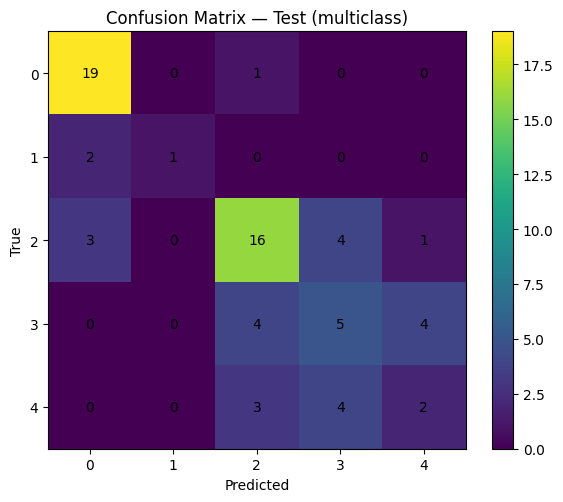

In [23]:
# --- Merge train + val and refit SVM (multiclass 0–4) ---
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

# Merge train + val
X_tv = np.concatenate([X_tr, X_va], axis=0)
y_tv = np.concatenate([y_tr, y_va], axis=0)

hp = best["hp"]

# Refit preprocessing
scaler = StandardScaler()
X_tv_s = scaler.fit_transform(X_tv)
X_te_s = scaler.transform(X_te)

pca = None
if hp.get("pca_dim") and hp["pca_dim"] > 0:
    pca = PCA(n_components=min(hp["pca_dim"], X_tv_s.shape[1]))
    X_tv_s = pca.fit_transform(X_tv_s)
    X_te_s = pca.transform(X_te_s)

# Refit SVM (multiclass by default; class_weight helps imbalances)
if hp["kernel"] == "linear":
    clf = SVC(kernel="linear", C=hp["C"], class_weight="balanced", probability=True, random_state=SEED)
else:
    clf = SVC(kernel="rbf", C=hp["C"], gamma=hp["gamma"], class_weight="balanced", probability=True, random_state=SEED)
clf.fit(X_tv_s, y_tv)

# --- Test predictions (multiclass) ---
# Get class scores (N, C)
if hasattr(clf, "predict_proba"):
    test_scores = clf.predict_proba(X_te_s)
elif hasattr(clf, "decision_function"):
    scores = clf.decision_function(X_te_s)
    # If binary returns (N,), convert to two columns; otherwise assume (N, C)
    if getattr(scores, "ndim", 1) == 1:
        scores = np.c_[-scores, scores]
    test_scores = scores
else:
    # Fallback: use predicted labels as one-hot scores
    preds = clf.predict(X_te_s)
    n_classes = getattr(clf, "n_classes_", None) or int(np.max(preds)) + 1
    test_scores = np.eye(n_classes)[preds]

test_scores = np.asarray(test_scores)
if test_scores.ndim != 2:
    raise ValueError(f"Expected (N, C) scores for multiclass evaluation, got shape: {getattr(test_scores, 'shape', None)}")

# Map argmax indices to class labels
classes = np.asarray(getattr(clf, "classes_", np.arange(test_scores.shape[1])))
test_pred_idx = np.argmax(test_scores, axis=1)
test_preds = classes[test_pred_idx]

# --- Metrics & report ---
def eval_and_print(y_true, preds, title):
    acc  = accuracy_score(y_true, preds)
    f1m  = f1_score(y_true, preds, average="macro")
    prec = precision_score(y_true, preds, average="macro", zero_division=0)
    rec  = recall_score(y_true, preds, average="macro", zero_division=0)
    print(f"{title} — Acc={acc:.4f} | Macro-F1={f1m:.4f} | Macro-Prec={prec:.4f} | Macro-Rec={rec:.4f}")

print("\n== Test metrics (multiclass) ==")
eval_and_print(y_te, test_preds, "SVM (argmax)")

print("\nClassification report (per class):")
print(classification_report(y_te, test_preds, labels=[0,1,2,3,4], digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_te, test_preds, labels=[0,1,2,3,4])
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix — Test (multiclass)")
plt.colorbar()
plt.xticks(range(5), [0,1,2,3,4])
plt.yticks(range(5), [0,1,2,3,4])
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()


In [25]:
# --- Save artifacts and test predictions (multiclass 0–4) ---
import numpy as np
import pandas as pd
import joblib
from pathlib import Path

OUT = Path("./outputs")
OUT.mkdir(parents=True, exist_ok=True)

# Ensure we have ids for the test set
if 'ids_te' not in globals():
    ids_te = np.arange(len(y_te))

# Ensure test scores/preds exist (multiclass)
if 'test_scores' not in globals():
    if hasattr(clf, "predict_proba"):
        test_scores = clf.predict_proba(X_te_s)  # (N, C)
    elif hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_te_s)
        if getattr(scores, "ndim", 1) == 1:
            # Binary fallback to two columns
            scores = np.c_[-scores, scores]
        test_scores = scores
    else:
        # Fallback: one-hot of predicted labels
        preds_tmp = clf.predict(X_te_s)
        n_classes = getattr(clf, "n_classes_", None) or int(np.max(preds_tmp)) + 1
        test_scores = np.eye(n_classes)[preds_tmp]

test_scores = np.asarray(test_scores)
if test_scores.ndim != 2:
    raise ValueError(f"Expected (N, C) scores for multiclass evaluation, got shape: {getattr(test_scores, 'shape', None)}")

classes = np.asarray(getattr(clf, "classes_", np.arange(test_scores.shape[1])))
pred_idx = np.argmax(test_scores, axis=1)
test_preds = classes[pred_idx]
confidence = test_scores[np.arange(len(test_scores)), pred_idx]

# Artifact (no binary threshold; store classes instead)
artifact = {
    "scaler": scaler,
    "pca": pca,
    "svm": clf,
    "hp": hp,
    "classes": classes,
}
joblib.dump(artifact, OUT / "svm_embedding_pipeline.pkl")

# Build a tidy predictions table with per-class probabilities
data = {
    "id_code": ids_te,
    "true": y_te,
    "pred": test_preds,
    "confidence": confidence,
}
for j, c in enumerate(classes):
    data[f"prob_{int(c)}"] = test_scores[:, j]

pd.DataFrame(data).to_csv(OUT / "test_predictions_svm.csv", index=False)

# (Optional) Save features; comment out if space is tight
np.save(OUT / "features_train.npy", X_tr)
np.save(OUT / "features_val.npy",   X_va)
np.save(OUT / "features_test.npy",  X_te)

print("Saved:")
print(" -", OUT / "svm_embedding_pipeline.pkl")
print(" -", OUT / "test_predictions_svm.csv")
print(" -", OUT / "features_{train,val,test}.npy")


Saved:
 - outputs/svm_embedding_pipeline.pkl
 - outputs/test_predictions_svm.csv
 - outputs/features_{train,val,test}.npy
